# Classificazione di frutti esotici

**TropicTaste Inc.**, leader nella distribuzione di frutti esotici, intende migliorare l'efficienza e l'accuratezza nel processo di classificazione dei frutti. L'obiettivo è sviluppare un modello di machine learning in grado di predire il tipo di frutto basandosi su caratteristiche numeriche.

## Problema
L'attuale processo di classificazione dei frutti esotici è:
- Manuale e soggetto a errori.
- Inefficiente e dispendioso in termini di risorse.

La necessità di un sistema automatizzato e preciso è cruciale per:
- Ottimizzare le operazioni aziendali.
- Mantenere alti standard qualitativi.

## Obiettivi
Implementando un modello di classificazione automatizzato, TropicTaste Inc. potrà:
- **Migliorare l'Efficienza Operativa**: Automatizzare la classificazione ridurrà il tempo e le risorse necessarie, aumentando la produttività.
- **Ridurre gli Errori Umani**: Un modello di machine learning minimizzerà gli errori di classificazione, garantendo una maggiore precisione.
- **Ottimizzare l'Inventario**: Una classificazione accurata permetterà una migliore gestione dell'inventario, assicurando condizioni ottimali di conservazione per ogni tipo di frutto.
- **Aumentare la Soddisfazione del Cliente**: Una corretta identificazione e classificazione dei frutti contribuirà a mantenere elevati standard di qualità, migliorando la soddisfazione dei clienti.

## Requisiti del Progetto

### Preparazione del Dataset
- Caricamento e preprocessamento dei dati sui frutti esotici.
- Gestione di eventuali valori mancanti, normalizzazione e scalatura dei dati.

### Implementazione del Modello KNN
- Sviluppo e addestramento del modello KNN.
- Ottimizzazione dei parametri per migliorare l'accuratezza predittiva.

### Valutazione delle Performance
- Utilizzo di tecniche di validazione incrociata per valutare la capacità di generalizzazione del modello.
- Calcolo delle metriche di performance, come l'accuratezza e l'errore di classificazione.

### Visualizzazione dei Risultati
- Creazione di grafici per visualizzare e confrontare le performance del modello.
- Analisi e interpretazione dei risultati per identificare eventuali aree di miglioramento.

# Implementazione

Il progetto implementa un'analisi per **Tropic Taste, inc**, al fine di automatizzare e ottimizzare la classificazione dei frutti esotici che distribuisce, utilizzando modelli di classificazione con tecniche di regolarizzazione e cross-validation. Il tutto corredato da analisi e grafici a sostegno dei risultati

## Caricamento del dataset

Il dataset rappresenta un insieme di osservazioni di frutti esotici, tracciandone alcune features:

- **Frutto**: Il tipo di frutto. Questa è la variabile di destinazione (target) che vogliamo prevedere.
- **Peso (g)**: Il peso del frutto in grammi. Variabile continua.
- **Diametro medio (mm)**: Il diametro medio del frutto in millimetri. Variabile continua.
- **Lunghezza media (mm)**: La lunghezza media del frutto in millimetri. Variabile continua.
- **Durezza buccia (1-10)**: La durezza della buccia del frutto su una scala da 1 a 10. Variabile continua.
- **Dolcezza (1-10)**: La dolcezza del frutto su una scala da 1 a 10. Variabile continua.
- **Acidità (1-10)**: L'acidità del frutto su una scala da 1 a 10. Variabile continua.

Non potendo contare su una conoscenza di dominio specifica e non potendo effettuare ulteriori analisi preliminari sui dati, essi verranno gestiti direttamente come forniti. Di seguito carichiamo il dataset e ne mostriamo un estratto:

In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

dataset = "https://proai-datasets.s3.eu-west-3.amazonaws.com/fruits.csv"

df = pd.read_csv(dataset)
df.head(5)

,Frutto,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
0,Mela,86.40,89.68,8.69,9.61,2.41
1,Mela,77.58,73.45,6.49,7.20,3.87
2,Mela,81.95,81.66,6.40,9.09,2.88
3,Mela,66.33,36.71,6.78,8.21,2.55
4,Mela,56.73,75.69,5.78,9.15,3.88


## Preprocessing dei dati

### Descrizione delle features

Analizziamo subito le features, valutando dati statistici e correlazione: questo ci consentirà di rimuovere dati poco informativi, ridurre la complessità del dataset, valutare le distribuzioni delle features, ottenendo possibili suggerimenti sulle trasformazioni che dovremo applicare.

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Frutto                 500 non-null    object 
 1   Peso (g)               500 non-null    float64
 2   Diametro medio (mm)    500 non-null    float64
 3   Lunghezza media (mm)   500 non-null    float64
 4   Durezza buccia (1-10)  500 non-null    float64
 5   Dolcezza (1-10)        500 non-null    float64
dtypes: float64(5), object(1)
memory usage: 23.6+ KB


### Verifica di valori mancanti

In [45]:
df.isna().sum()

Frutto                   0
Peso (g)                 0
Diametro medio (mm)      0
Lunghezza media (mm)     0
Durezza buccia (1-10)    0
Dolcezza (1-10)          0
dtype: int64

Il dataset, come si evince dal risultato, non presenta valori mancanti, perciò possiamo procedere ulteriormente.

Prima di effettuare la verifica della correlazione, facciamo un passaggio di LabelEncoder della variabile target:

In [46]:
from sklearn.calibration import LabelEncoder

le = LabelEncoder()
df["Frutto"] = le.fit_transform(df["Frutto"])

E creiamo quindi la matrice di correlazione, con coefficiente di Pearson:

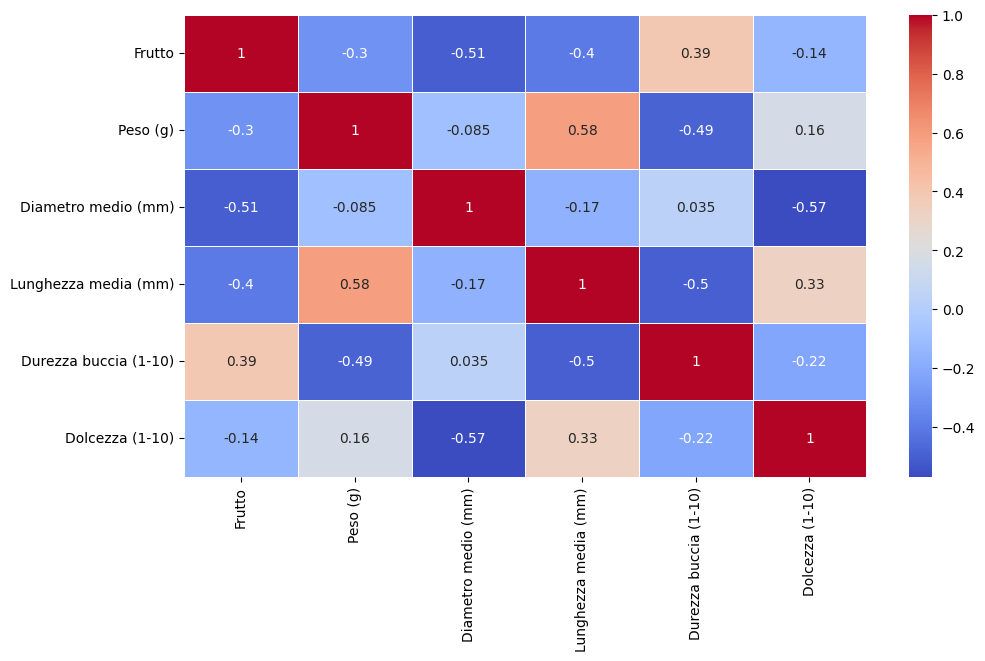

In [47]:
# Feature Correlation Analysis for numerical variables

plt.figure(figsize=(11, 6))

sns.heatmap(df.corr(method="pearson"), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

Dall'analisi della matrice sopra mostrata, le features sembrano avere quasi tutte un impatto quantomeno discreto sul target (si è scelto **0.10** come valore soglia). Inoltre, la correlazione tra features non presenta picchi tali da giustificare la rimozione di una di esse (con il treshold scelto di **0.75**).

### Verifica delle distribuzioni

Mostriamo ora una rappresentazione delle distribuzioni del target, per verificare se sono necessari interventi di regolarizzazione.

Defininiamo, innanzitutto, le funzioni di stampa dei grafici (boxplot, per verifica dei range interquartili e dell'istogramma per la rappresentazione grafica della distribuzione):

In [48]:
#Boxplot for target distribution

def show_boxplot(feature, is_target=False):
    """
    Shows a boxplot for a given feature.

    Feature: the feature to analyze.
    """

    plt.figure(figsize=(10, 5))
    sns.boxplot(feature, orient="h", color="lightblue")

    if(is_target):
        plt.title("Distribuzione del target")
    else:
        plt.title(f"Distribuzione della feature {feature.name}")
        
    plt.show()

In [49]:
def show_histogram(feature):
    """
    Shows a histogram for a given feature.

    Feature: the feature to analyze.
    """

    plt.figure(figsize=(10, 5))
    sns.histplot(feature, bins=30, kde=True, color="lightblue")
    plt.title(f"Distribuzione della feature {feature.name}")
    plt.xlabel(feature.name)
    plt.ylabel("Frequenza")
    plt.show()

Calcoliamo i valori statistici:

In [50]:
df.describe()

,Frutto,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2.00000,47.313440,86.573100,5.298620,7.437640,3.593220
std,1.41563,26.768797,64.293403,2.641993,1.812548,1.264899
min,0.00000,8.570000,7.530000,1.150000,3.070000,1.250000
25%,1.00000,24.797500,50.510000,2.672500,6.152500,2.570000
50%,2.00000,42.380000,70.450000,5.670000,7.340000,3.535000
75%,3.00000,68.080000,88.852500,7.455000,8.615000,4.465000
max,4.00000,111.210000,299.890000,11.140000,13.720000,6.950000


E mostriamo ora tali grafici per il Target:

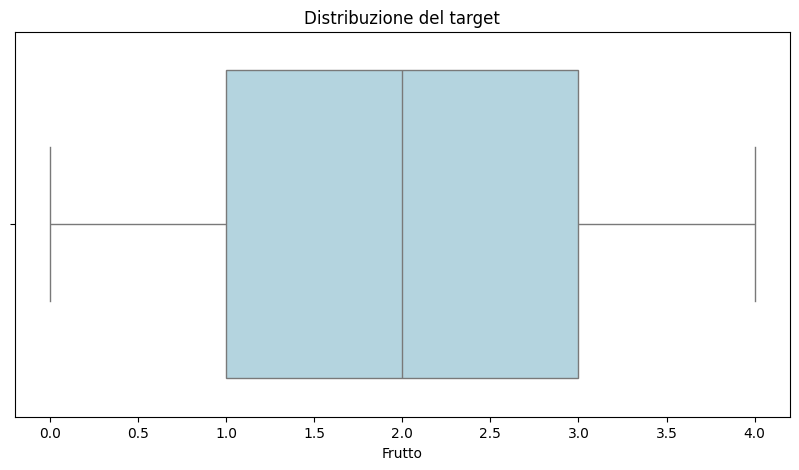

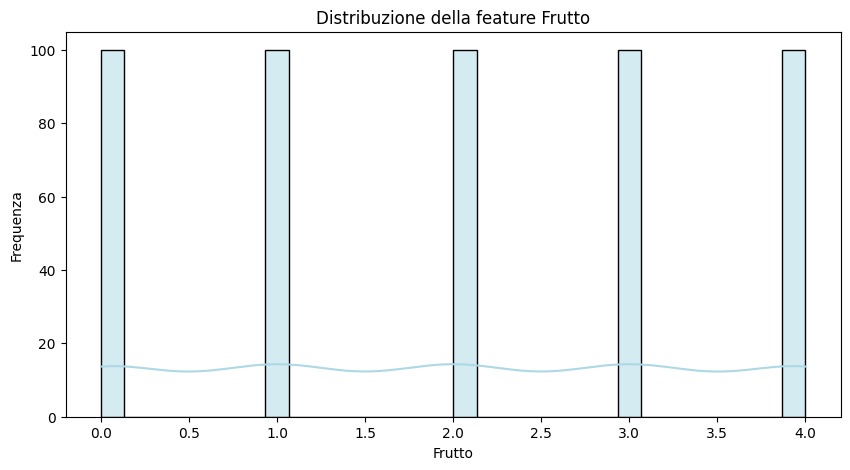

In [51]:
# Target distribution

y = df["Frutto"]

show_boxplot(y, is_target=True)
show_histogram(y)

I grafici mostrano (come deducibile anche dall'analisi delle metriche - df.describe()) che la distribuzione è perfettamente omogenea, con lo stesso numero di osservazioni per classe. Non sono quindi necessari passaggi di tecniche di generazione di sample sintetici come lo SMOTE.

Mostriamo ora le distribuzioni per le features:

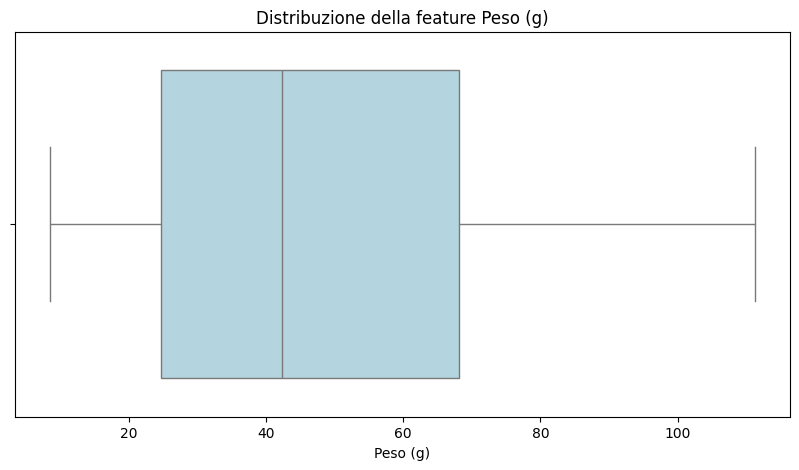

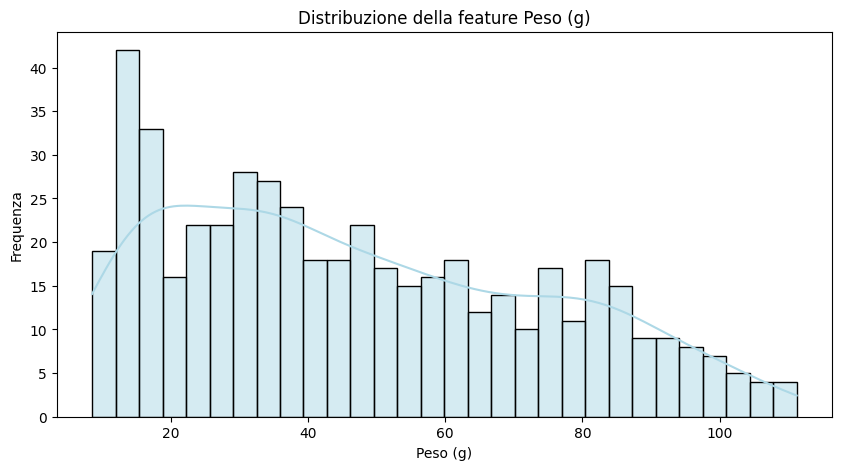

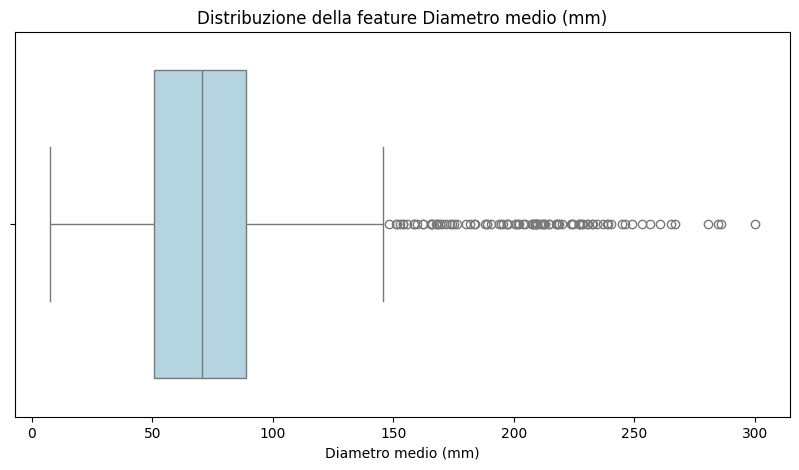

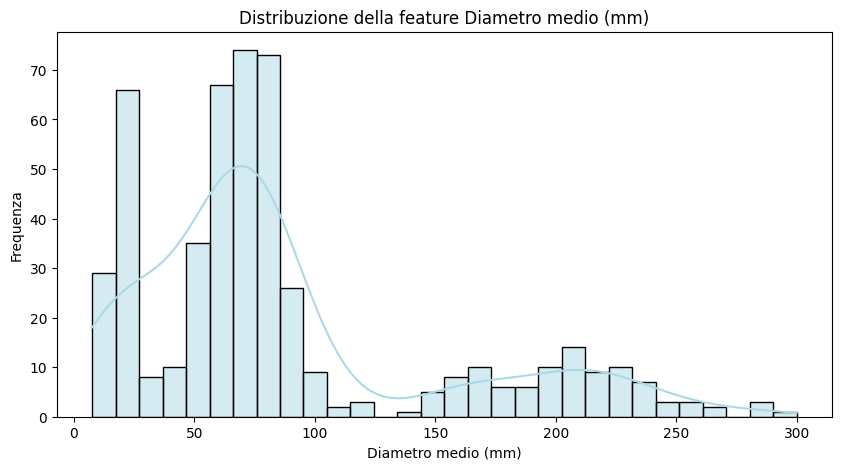

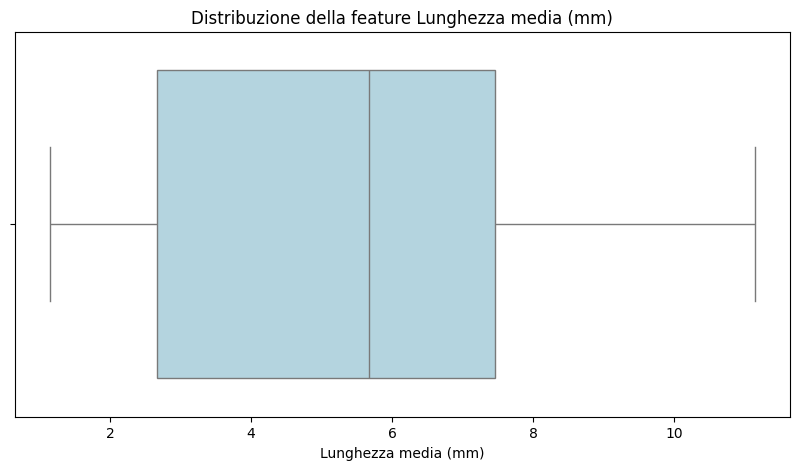

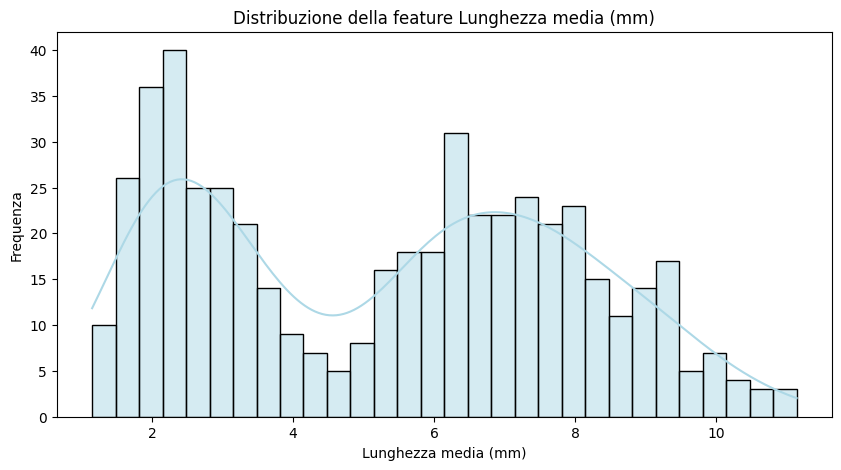

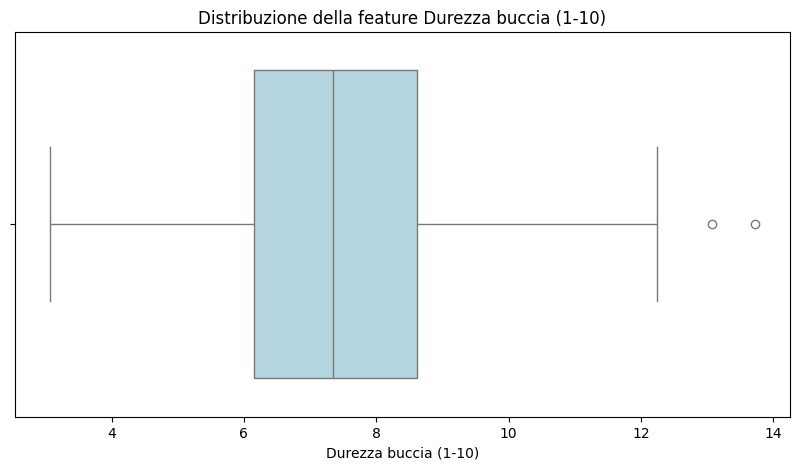

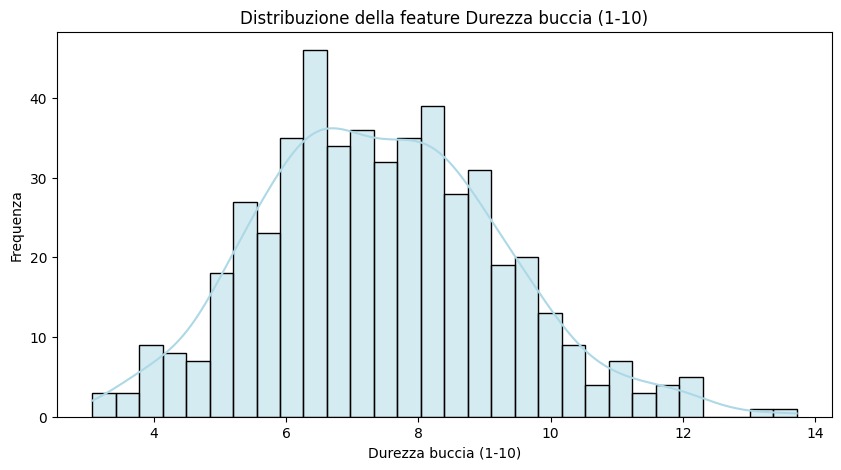

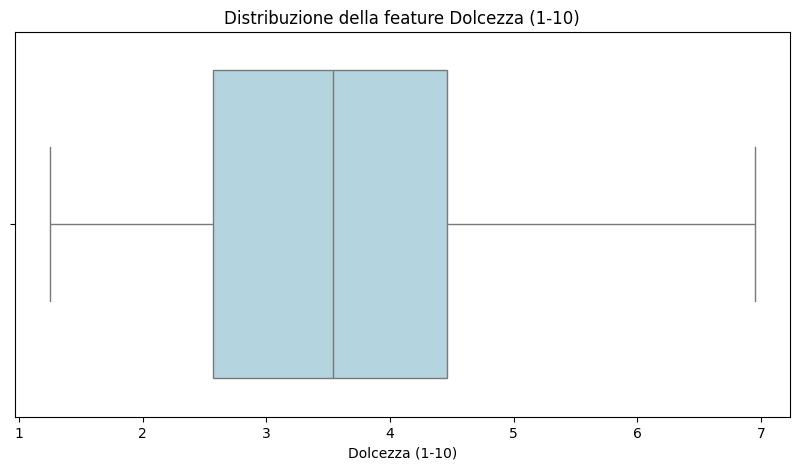

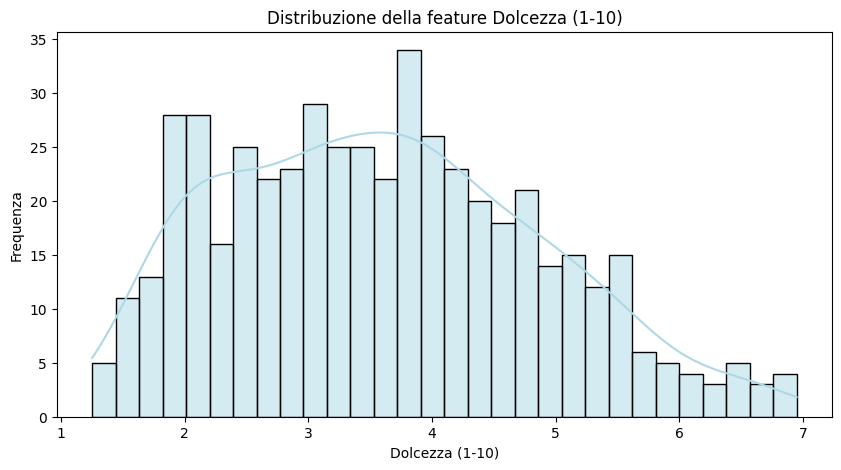

In [52]:
# Feature distribution analysis

X = df.drop(columns=["Frutto"])

for feature in X.columns:
    if feature == "Frutto":
        continue

    show_boxplot(X[feature])
    show_histogram(X[feature])

In questo caso, abbiamo la feature **Diametro Medio** con distribuzione positivamente asimmetrica e elevata deviazione standard.

Applicheremo alla feature la trasformazione *Logaritmo* per ridurla, dato che il modello KNN che addestreremo è sensibile agli outliers. Da alcuni test effettuati, performa meglio della radice quadrata e del RobustScaler.

In [53]:
#Log transformation
from sklearn.base import BaseEstimator, TransformerMixin

class LogTransform(BaseEstimator, TransformerMixin): 
    """
    Applies a log transformation to the input data.

    x: the input data.
    """

    def __init__(self, input_features):
        self.input_features = input_features

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return np.log1p(X)

    def inverse_transform(self, X, y=None):
        return np.expm1(X)
    
    def get_feature_names_out(self, input_features):

        feature_names = []

        for feature in self.input_features:
            feature_names.append(f"{feature}_log")

        return feature_names

**Lunghezza Media**, nonostante anch'essa presenti un'asimmetria, non verrà comunque modificata ulteriormente (ad eccezione dello scaling, che verrà applicato successivamente).

Le altre features invece sembrano già sufficientemente bilanciate.

### Scaling delle features

Effettuiamo lo scaling delle features, necessario a supporto delle simmetrie delle distribuzioni e per l'ottimizzazione della scala di valori per il modello KNN. Qui istanziamo il trasformatore, lo scaling verrà fatto durante le tecniche di cross validation successivamente.

In [54]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

### Analisi delle variabili categoriche

Come già visualizzato in precedenza, le features sono solamente esclusivamente numerici. Non risultano necessarie quindi trasformazioni di variabili categoriche come il One-Hot Encoding o il Label Encoding.

### Pipeline di trasformazione

Definiamo, infine, la nostra pipeline di trasformazione delle features:

In [56]:
from sklearn.compose import ColumnTransformer

feature_names = list(df.columns.drop(["Frutto"]))

print(feature_names)

feature_transformer = ColumnTransformer(
    transformers=[
        ("log_transformer", LogTransform(input_features=feature_names), [2]),
        
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

X = feature_transformer.fit_transform(X)

X = pd.DataFrame(X, columns=feature_transformer.get_feature_names_out())

# X["Diametro medio (mm)"] = np.log1p(X["Diametro medio (mm)"])

# show_boxplot(X["Diametro medio (mm)"])
# show_histogram(X["Diametro medio (mm)"])

['Peso (g)', 'Diametro medio (mm)', 'Lunghezza media (mm)', 'Durezza buccia (1-10)', 'Dolcezza (1-10)']


ValueError: Shape of passed values is (500, 5), indices imply (500, 9)

## Addestramento del modello KNN

## Valutazione delle performance

## Visualizzazione dei risultati